# Porto Seguro – Best of Modellierung


## 1. Bibliotheken und Einstellungen


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
N_JOBS = 4
N_ITER_KOMPAKT = 20
N_ITER_ERWEITERT = 25
CV_FOLDS = 3
EXPERIMENT_FRACTION = 1.0
SPLIT_DIR = Path("data/processed")

## 2. OpenML-Daten und gemeinsamer Datensplit


In [2]:
daten = fetch_openml(data_id=42742, as_frame=True).frame
y = pd.to_numeric(daten["target"].astype(object), errors="raise").to_numpy(dtype="int8")
X = daten.drop(columns=["target", "id"], errors="ignore")
X = X.apply(lambda s: pd.to_numeric(s.astype(object), errors="raise"))
X = X.replace(-1, np.nan).astype("float32")
assert X.shape == (595_212, 57) and set(np.unique(y)) == {0, 1}

cat_cols = [c for c in X if c.endswith("_cat")]
bin_cols = [c for c in X if c.endswith("_bin")]
num_cols = [c for c in X if c not in cat_cols + bin_cols]


In [3]:
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
split_files = [SPLIT_DIR / f"{name}_idx.npy" for name in ["train", "val", "test"]]
if any(p.exists() for p in split_files) and not all(p.exists() for p in split_files):
    raise FileNotFoundError("Im Split-Ordner fehlen Indexdateien: train, val und test werden benötigt.")

if all(p.exists() for p in split_files):
    idx_train, idx_val, idx_test = [np.load(p, allow_pickle=False) for p in split_files]
else:
    idx_train, idx_rest = train_test_split(
        np.arange(len(y)), test_size=0.20, stratify=y, random_state=SEED
    )
    idx_val, idx_test = train_test_split(
        idx_rest, test_size=0.50, stratify=y[idx_rest], random_state=SEED
    )
    for path, indices in zip(split_files, [idx_train, idx_val, idx_test]):
        np.save(path, indices)

for indices in [idx_train, idx_val, idx_test]:
    assert indices.ndim == 1 and np.issubdtype(indices.dtype, np.integer)
alle_idx = np.concatenate([idx_train, idx_val, idx_test])
assert len(alle_idx) == len(y) and len(np.unique(alle_idx)) == len(y)
assert alle_idx.min() == 0 and alle_idx.max() == len(y) - 1
assert np.allclose([len(i) / len(y) for i in [idx_train, idx_val, idx_test]],
                   [0.8, 0.1, 0.1], atol=2 / len(y))
assert all(len(np.unique(y[i])) == 2 for i in [idx_train, idx_val, idx_test])

# Alle Versuche nutzen dieselbe Trainingsstichprobe und dieselbe Validierungsmenge
assert 0 < EXPERIMENT_FRACTION <= 1
if EXPERIMENT_FRACTION < 1:
    idx_exp, _ = train_test_split(idx_train, train_size=EXPERIMENT_FRACTION,
                                stratify=y[idx_train], random_state=SEED)
else:
    idx_exp = idx_train.copy()
X_exp, y_exp = X.iloc[idx_exp], y[idx_exp]
X_val, y_val = X.iloc[idx_val], y[idx_val]
print(f"Experimente: {len(idx_exp):,} | Validierung: {len(idx_val):,} | Test: {len(idx_test):,}")


Experimente: 476,169 | Validierung: 59,521 | Test: 59,522


## 3. Vorverarbeitung und Bewertung


In [4]:
# fehlende Werte und nominale Kategorien werden getrennt behandelt
prep_logreg = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("bin", SimpleImputer(strategy="most_frequent"), bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50,
                          sparse_output=True, dtype=np.float32), cat_cols),
], sparse_threshold=1.0)

prep_xgb = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50,
                          sparse_output=False, dtype=np.float32), cat_cols),
    ("num", "passthrough", num_cols + bin_cols),
], sparse_threshold=0)

def logreg_modell(C):
    return Pipeline([("prep", clone(prep_logreg)),
                     ("model", LogisticRegression(C=C, class_weight=None, solver="lbfgs",
                                                  max_iter=1000, random_state=SEED))])

def xgb_modell(params):
    return Pipeline([("prep", clone(prep_xgb)),
                     ("model", XGBClassifier(objective="binary:logistic", eval_metric="auc",
                                             tree_method="hist", n_jobs=N_JOBS,
                                             random_state=SEED, **params))])

def rf_modell(params):
    return RandomForestClassifier(n_jobs=N_JOBS, random_state=SEED, **params)

def bewerten(name, modell):
    modell.fit(X_exp, y_exp)
    # AUC bezeichnet hier ROC-AUC. Gini = 2 * AUC - 1.
    auc_train = roc_auc_score(y_exp, modell.predict_proba(X_exp)[:, 1])
    auc_val = roc_auc_score(y_val, modell.predict_proba(X_val)[:, 1])
    return {"Variante": name, "AUC Train": auc_train, "AUC Val": auc_val,
            "Gini Val": 2 * auc_val - 1}


## 4. Logistische Regression – Baseline und stärkere Regularisierung


In [5]:
# Kleineres C bedeutet stärkere Regularisierung; die Suche wird nicht erneut ausgeführt.
logreg_varianten = {"Baseline (C=1)": 1.0, "Stärkere Regularisierung (C=0.01)": 0.01}
logreg_ergebnisse = pd.DataFrame([
    bewerten(name, logreg_modell(C)) for name, C in logreg_varianten.items()
]).set_index("Variante")
display(logreg_ergebnisse.round(4))


,AUC Train,AUC Val,Gini Val
Variante,,,
Baseline (C=1),0.6347,0.6270,0.2541
Stärkere Regularisierung (C=0.01),0.6335,0.6279,0.2558


## 5. XGBoost – ausgewählte Konfigurationen und Sensitivität


In [6]:
xgb_baseline = dict(n_estimators=100, learning_rate=0.3, max_depth=6,
                    min_child_weight=1, subsample=1.0, colsample_bytree=1.0,
                    gamma=0.0, reg_alpha=0.0, reg_lambda=1.0)

xgb_referenz = dict(n_estimators=400, learning_rate=0.035, max_depth=2,
                    min_child_weight=30, subsample=0.8, colsample_bytree=0.8,
                    gamma=0.0, reg_alpha=0.0, reg_lambda=1.0)

xgb_fruehere_suche = {**xgb_referenz, "n_estimators": 395,
                     "learning_rate": 0.0256402008378338, "max_depth": 2,
                     "min_child_weight": 20, "subsample": 0.878206434570451,
                     "colsample_bytree": 0.610167650697638}

xgb_varianten = {
    "Baseline": xgb_baseline,
    "Regularisierte Referenz": xgb_referenz,
    "Höhere Baumtiefe (4)": {**xgb_referenz, "max_depth": 4},
    "Höhere Lernrate (0.1)": {**xgb_referenz, "learning_rate": 0.1},
    "Stärkere L2-Regularisierung (10)": {**xgb_referenz, "reg_lambda": 10.0},
    "Früheres Suchergebnis": xgb_fruehere_suche,
}
xgb_ergebnisse = pd.DataFrame([
    bewerten(name, xgb_modell(params)) for name, params in xgb_varianten.items()
]).set_index("Variante")
display(xgb_ergebnisse.round(4))


,AUC Train,AUC Val,Gini Val
Variante,,,
Baseline,0.7883,0.6191,0.2382
Regularisierte Referenz,0.6429,0.6363,0.2726
Höhere Baumtiefe (4),0.6681,0.6410,0.2820
Höhere Lernrate (0.1),0.6538,0.6387,0.2773
Stärkere L2-Regularisierung (10),0.6428,0.6363,0.2727
Früheres Suchergebnis,0.6397,0.6348,0.2695


## 6. XGBoost – Hyperparametersuche mit Kreuzvalidierung


In [7]:
# Suchräume aus den früheren Notebooks, neuer Lauf auf dem hier eingestellten X_exp
# Vorverarbeitung wird innerhalb jedes CV-Folds ausschließlich auf dessen Trainingsdaten gefittet
# Die 10-%-Validierung und der 10-%-Testsplit werden nicht für die CV-Suchen verwendet
search_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
print(f"Suchdaten: {len(X_exp):,} Zeilen | CV-Folds: {CV_FOLDS}")
print(f"Geplante CV-Fits: ({N_ITER_KOMPAKT} + {N_ITER_ERWEITERT}) × {CV_FOLDS} "
      f"= {(N_ITER_KOMPAKT + N_ITER_ERWEITERT) * CV_FOLDS}")

def hyperparametersuche(name, suchraum, n_iter):
    suche = RandomizedSearchCV(
        estimator=xgb_modell({}),
        param_distributions={f"model__{key}": value for key, value in suchraum.items()},
        n_iter=n_iter, scoring="roc_auc", cv=search_cv,
        refit=False, return_train_score=True, error_score="raise",
        random_state=SEED, n_jobs=1, verbose=1,
    )
    print(f"{name}: {n_iter} Parameterkombinationen × {CV_FOLDS} Folds", flush=True)
    suche.fit(X_exp, y_exp)

    # 'test_score' bezeichnet hier den jeweiligen CV-Validierungsfold, nicht den Testsplit
    cv_ergebnisse = pd.DataFrame(suche.cv_results_)
    cv_ergebnisse["Gini CV-Validierung"] = 2 * cv_ergebnisse["mean_test_score"] - 1
    parameter_spalten = [f"param_model__{key}" for key in suchraum]
    tabelle = cv_ergebnisse.sort_values("rank_test_score", kind="stable")[[
        "rank_test_score", "mean_train_score", "mean_test_score", "std_test_score",
        "Gini CV-Validierung", *parameter_spalten,
    ]].rename(columns={
        "rank_test_score": "Rang CV", "mean_train_score": "AUC CV-Train",
        "mean_test_score": "AUC CV-Validierung", "std_test_score": "Std AUC CV",
        **{f"param_model__{key}": key for key in suchraum},
    }).reset_index(drop=True)
    # Alle tatsächlich geprüften Kombinationen werden angezeigt, nicht nur die beste
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(tabelle.round(4))
    beste_parameter = {key.removeprefix("model__"): value
                       for key, value in suche.best_params_.items()}
    print("Beste mittlere CV-AUC:", f"{suche.best_score_:.4f}")
    display(pd.DataFrame([beste_parameter]))
    return suche, beste_parameter, tabelle


Suchdaten: 476,169 Zeilen | CV-Folds: 3
Geplante CV-Fits: (20 + 25) × 3 = 135


### 6.1 XGBoost – Suchraum mit sechs Hyperparametern


In [8]:
suchraum_kompakt = {
    "n_estimators": randint(300, 901),       # 300 bis 900 Bäume
    "learning_rate": loguniform(0.02, 0.20),
    "max_depth": randint(2, 7),             # mögliche Tiefen: 2, 3, 4, 5, 6
    "min_child_weight": randint(1, 31),     # 1 bis 30
    "subsample": uniform(0.60, 0.40),       # 0.60 bis 1.00
    "colsample_bytree": uniform(0.60, 0.40),
}
suche_kompakt, parameter_kompakt, tabelle_kompakt = hyperparametersuche(
    "Randomized Search (6 Parameter)", suchraum_kompakt, N_ITER_KOMPAKT
)


Randomized Search (6 Parameter): 20 Parameterkombinationen × 3 Folds
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,Rang CV,AUC CV-Train,AUC CV-Validierung,Std AUC CV,Gini CV-Validierung,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree
0,1,0.6870,0.6396,0.0031,0.2792,892,0.0203,4,19,0.8845,0.6795
1,2,0.7336,0.6391,0.0037,0.2782,430,0.0229,6,4,0.6082,0.6624
2,3,0.6935,0.6388,0.0033,0.2776,506,0.0344,4,9,0.7710,0.8887
3,4,0.6784,0.6382,0.0032,0.2764,340,0.0807,3,7,0.9660,0.9161
4,5,0.6647,0.6380,0.0034,0.2760,855,0.0215,3,26,0.9758,0.8271
5,6,0.6940,0.6378,0.0025,0.2757,335,0.0804,4,29,0.9771,0.6557
6,7,0.7086,0.6378,0.0030,0.2756,334,0.0551,5,29,0.9637,0.8737
7,8,0.6802,0.6377,0.0032,0.2754,487,0.0693,3,25,0.8171,0.8989
8,9,0.7145,0.6372,0.0029,0.2745,866,0.0392,4,12,0.9933,0.6558
9,10,0.6631,0.6372,0.0029,0.2744,802,0.0563,2,16,0.7244,0.9400


Beste mittlere CV-AUC: 0.6396


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample
0,0.679486,0.020256,4,19,892,0.884537


### 6.2 XGBoost – Erweiterter Suchraum mit zehn Hyperparametern


In [9]:
# Randomized Search zieht Kombinationen; sie prüft nicht das vollständige kartesische Produkt
suchraum_erweitert = {
    "n_estimators": randint(200, 1601),      # 200 bis 1600 Bäume
    "learning_rate": loguniform(0.005, 0.15),
    "max_depth": randint(1, 6),             # mögliche Tiefen: 1, 2, 3, 4, 5
    "min_child_weight": randint(5, 61),     # 5 bis 60
    "subsample": uniform(0.60, 0.40),
    "colsample_bytree": uniform(0.50, 0.50),
    "gamma": loguniform(1e-3, 2.0),
    "reg_alpha": loguniform(1e-4, 3.0),
    "reg_lambda": loguniform(0.05, 20.0),
    "max_bin": [128, 256, 512],
}
suche_erweitert, parameter_erweitert, tabelle_erweitert = hyperparametersuche(
    "Randomized Search (10 Parameter)", suchraum_erweitert, N_ITER_ERWEITERT
)


Randomized Search (10 Parameter): 25 Parameterkombinationen × 3 Folds
Fitting 3 folds for each of 25 candidates, totalling 75 fits


,Rang CV,AUC CV-Train,AUC CV-Validierung,Std AUC CV,Gini CV-Validierung,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,max_bin
0,1,0.6981,0.6399,0.0032,0.2798,883,0.0176,5,39,0.7889,0.7247,0.0021,0.0715,10.1754,256
1,2,0.6767,0.6396,0.0035,0.2793,919,0.0152,4,44,0.8347,0.9633,0.2516,0.2217,1.2685,256
2,3,0.7025,0.6394,0.0029,0.2787,720,0.0128,5,5,0.6022,0.9826,0.1009,0.2867,0.1645,128
3,4,0.7043,0.6389,0.0035,0.2779,321,0.0603,5,43,0.9465,0.6873,1.3751,0.0005,0.0708,128
4,5,0.6728,0.6388,0.0030,0.2775,430,0.0146,5,27,0.6915,0.5157,0.1261,0.0069,4.6234,256
5,6,0.6723,0.6382,0.0033,0.2765,430,0.0597,3,9,0.9400,0.9077,0.2155,0.0822,12.0157,128
6,7,0.6606,0.6378,0.0031,0.2755,597,0.0107,4,37,0.8599,0.8459,0.1420,0.0029,4.3791,128
7,8,0.7251,0.6375,0.0030,0.2749,846,0.0375,5,55,0.9796,0.5998,0.0498,0.0006,0.0738,512
8,9,0.6580,0.6372,0.0029,0.2744,1527,0.0290,2,5,0.9531,0.5875,1.7465,2.1004,1.4180,128
9,10,0.6746,0.6372,0.0034,0.2744,253,0.0541,4,28,0.6337,0.5944,0.0083,0.3102,2.3419,512


Beste mittlere CV-AUC: 0.6399


,colsample_bytree,gamma,learning_rate,max_bin,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample
0,0.724725,0.002065,0.017649,256,5,39,883,0.071519,10.175383,0.788886


### 6.3 XGBoost – Suchergebnisse auf dem gemeinsamen Validierungssplit


In [10]:
# Beide CV-Gewinner werden separat auf X_exp trainiert und auf X_val bewertet
# Die frühere Parameterkombination mit Tiefe 2 bleibt als eigene Variante erhalten
xgb_suchparameter = {
    "Randomized Search (6 Parameter)": parameter_kompakt,
    "Randomized Search (10 Parameter)": parameter_erweitert,
}
xgb_suchergebnisse = pd.DataFrame([
    bewerten(name, xgb_modell(params)) for name, params in xgb_suchparameter.items()
]).set_index("Variante")
xgb_gesamt_ergebnisse = pd.concat([xgb_ergebnisse, xgb_suchergebnisse])
display(xgb_gesamt_ergebnisse.round(4))


,AUC Train,AUC Val,Gini Val
Variante,,,
Baseline,0.7883,0.6191,0.2382
Regularisierte Referenz,0.6429,0.6363,0.2726
Höhere Baumtiefe (4),0.6681,0.6410,0.2820
Höhere Lernrate (0.1),0.6538,0.6387,0.2773
Stärkere L2-Regularisierung (10),0.6428,0.6363,0.2727
Früheres Suchergebnis,0.6397,0.6348,0.2695
Randomized Search (6 Parameter),0.6763,0.6400,0.2801
Randomized Search (10 Parameter),0.6845,0.6416,0.2831


## 7. Random Forest – Modellkomplexität und bisherige Optimierung


In [11]:
rf_baseline = dict(n_estimators=150, max_depth=10, min_samples_leaf=50,
                   max_features="sqrt", class_weight="balanced_subsample")
rf_varianten = {
    "Baseline (Tiefe 10, Blatt 50)": rf_baseline,
    "Flach (Tiefe 6, Blatt 100)": {**rf_baseline, "max_depth": 6, "min_samples_leaf": 100},
    "Komplex (Tiefe 14, Blatt 20)": {**rf_baseline, "max_depth": 14, "min_samples_leaf": 20},
    "Frühere optimierte Konfiguration": {**rf_baseline, "n_estimators": 300,
                                         "max_depth": 6, "min_samples_leaf": 100,
                                         "class_weight": "balanced"},
}
rf_ergebnisse = pd.DataFrame([
    bewerten(name, rf_modell(params)) for name, params in rf_varianten.items()
]).set_index("Variante")
display(rf_ergebnisse.round(4))


,AUC Train,AUC Val,Gini Val
Variante,,,
"Baseline (Tiefe 10, Blatt 50)",0.7219,0.6285,0.2570
"Flach (Tiefe 6, Blatt 100)",0.6403,0.6263,0.2525
"Komplex (Tiefe 14, Blatt 20)",0.9155,0.6168,0.2336
Frühere optimierte Konfiguration,0.6397,0.6269,0.2539


## 8. XGBoost und Random Forest – Trainings- und Validierungsleistung


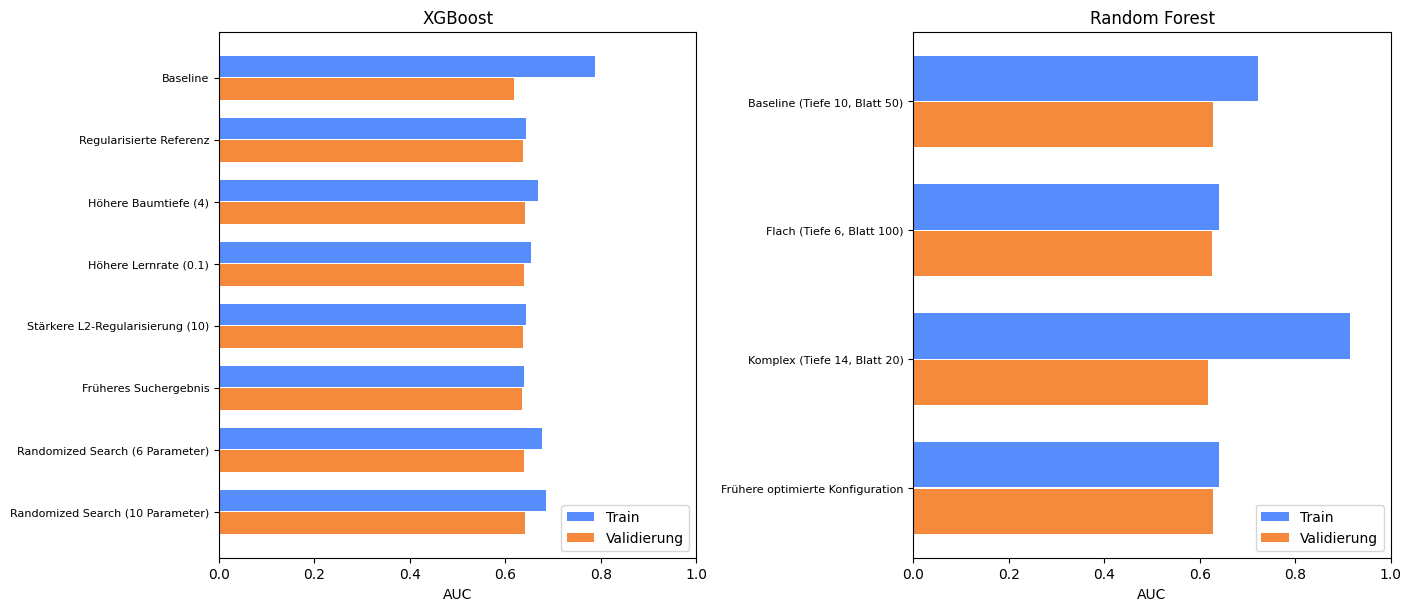

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
for ax, titel, tabelle in zip(axes, ["XGBoost", "Random Forest"], [xgb_gesamt_ergebnisse, rf_ergebnisse]):
    positionen = np.arange(len(tabelle))
    ax.barh(positionen - 0.18, tabelle["AUC Train"], height=0.35, label="Train")
    ax.barh(positionen + 0.18, tabelle["AUC Val"], height=0.35, label="Validierung")
    ax.set_yticks(positionen, tabelle.index, fontsize=8)
    ax.invert_yaxis()
    ax.set(xlabel="AUC", title=titel, xlim=(0, 1))
    ax.legend()
plt.show()


## 9. Modellkonfigurationen für den abschließenden Vergleich


In [13]:
# Auswahl mit ungerundeten Validierungswerten, der Test beeinflusst sie nicht
logreg_auswahl = logreg_ergebnisse["AUC Val"].idxmax()
# Historische Auswahl beibehalten, die beiden neuen CV-Gewinner kommen ergänzend hinzu
xgb_auswahl = "Früheres Suchergebnis"
rf_auswahl = rf_ergebnisse["AUC Val"].idxmax()
display(pd.DataFrame({"Modell": ["LogReg", "XGBoost", "Random Forest"],
                      "Ausgewählte Variante": [logreg_auswahl, xgb_auswahl, rf_auswahl]}))


,Modell,Ausgewählte Variante
0,LogReg,Stärkere Regularisierung (C=0.01)
1,XGBoost,Früheres Suchergebnis
2,Random Forest,"Baseline (Tiefe 10, Blatt 50)"


## 10. Gemeinsamer Modellvergleich – AUC und Gini auf dem Testsplit


In [14]:
idx_train_val = np.concatenate([idx_train, idx_val])
X_train_val, y_train_val = X.iloc[idx_train_val], y[idx_train_val]
X_test, y_test = X.iloc[idx_test], y[idx_test]

finale_modelle = {
    "LogReg (Baseline)": logreg_modell(1.0),
    "XGBoost (Baseline)": xgb_modell(xgb_baseline),
    "Random Forest (Baseline)": rf_modell(rf_baseline),
}
if logreg_auswahl != "Baseline (C=1)":
    finale_modelle["LogReg (Auswahl)"] = logreg_modell(logreg_varianten[logreg_auswahl])
if xgb_auswahl != "Baseline":
    finale_modelle["XGBoost (frühere Parameter, Tiefe 2)"] = xgb_modell(xgb_varianten[xgb_auswahl])
if rf_auswahl != "Baseline (Tiefe 10, Blatt 50)":
    finale_modelle["Random Forest (Auswahl)"] = rf_modell(rf_varianten[rf_auswahl])

finale_modelle.update({f"XGBoost ({name})": xgb_modell(params)
                       for name, params in xgb_suchparameter.items()})

testergebnisse, testprognosen = [], {}
for name, modell in finale_modelle.items():
    print(f"Trainiere {name} …", flush=True)
    modell.fit(X_train_val, y_train_val)
    proba = modell.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    testergebnisse.append({"Modell": name, "AUC": auc, "Gini": 2 * auc - 1})
    testprognosen[name] = proba

modellvergleich = pd.DataFrame(testergebnisse).set_index("Modell")
display(modellvergleich.round(4))


Trainiere LogReg (Baseline) …
Trainiere XGBoost (Baseline) …
Trainiere Random Forest (Baseline) …
Trainiere LogReg (Auswahl) …
Trainiere XGBoost (frühere Parameter, Tiefe 2) …
Trainiere XGBoost (Randomized Search (6 Parameter)) …
Trainiere XGBoost (Randomized Search (10 Parameter)) …


,AUC,Gini
Modell,,
LogReg (Baseline),0.6371,0.2741
XGBoost (Baseline),0.6211,0.2423
Random Forest (Baseline),0.6276,0.2551
LogReg (Auswahl),0.6375,0.2751
"XGBoost (frühere Parameter, Tiefe 2)",0.6399,0.2799
XGBoost (Randomized Search (6 Parameter)),0.6479,0.2958
XGBoost (Randomized Search (10 Parameter)),0.6466,0.2932


## 11. Modellvergleich – ROC-Kurven


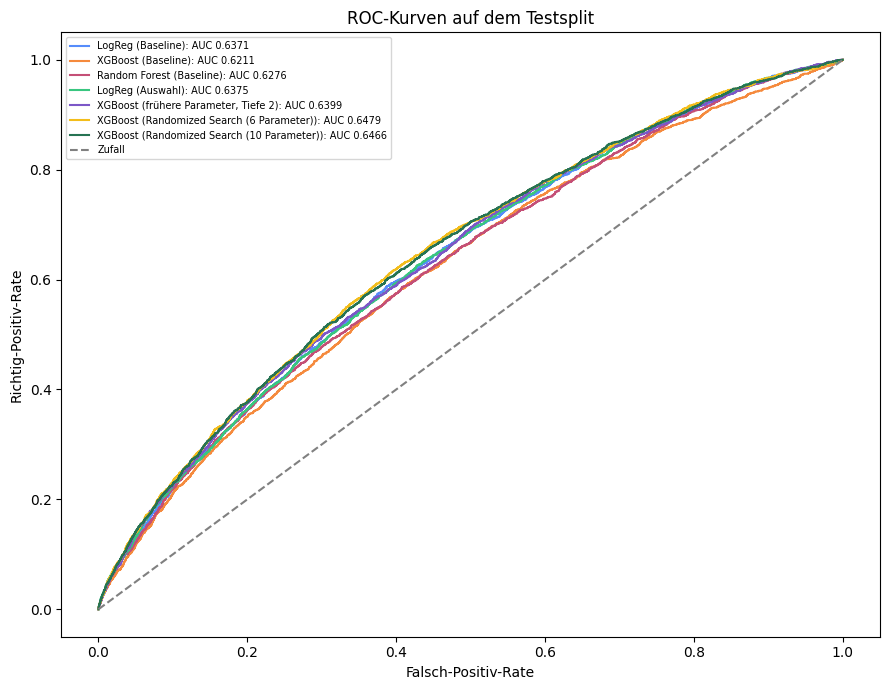

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
for name, proba in testprognosen.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = modellvergleich.loc[name, "AUC"]
    ax.plot(fpr, tpr, label=f"{name}: AUC {auc:.4f}")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Zufall")
ax.set(xlabel="Falsch-Positiv-Rate", ylabel="Richtig-Positiv-Rate", title="ROC-Kurven auf dem Testsplit")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()
